In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [15]:
df = pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [16]:
df.shape

(1200, 14)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [18]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [21]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [22]:
df["Date"] = pd.to_datetime(df["Date"])

In [23]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

In [24]:
df["AverageItemPrice"] = (
    df["TotalPrice"] /
    df["Quantity"]
)

In [25]:
high_amount = df["TotalPrice"].quantile(0.90)

high_quantity = df["Quantity"].quantile(0.90)


df["Risk_Flag"] = np.where(
    (df["TotalPrice"] > high_amount) |
    (df["Quantity"] > high_quantity),
    1,
    0
)

In [26]:
df["Risk_Flag"].value_counts()

,count
Risk_Flag,
0,1080
1,120


In [27]:
(
df["Risk_Flag"]
.value_counts(normalize=True)
.mul(100)
.round(2)
)

,proportion
Risk_Flag,
0,90.0
1,10.0


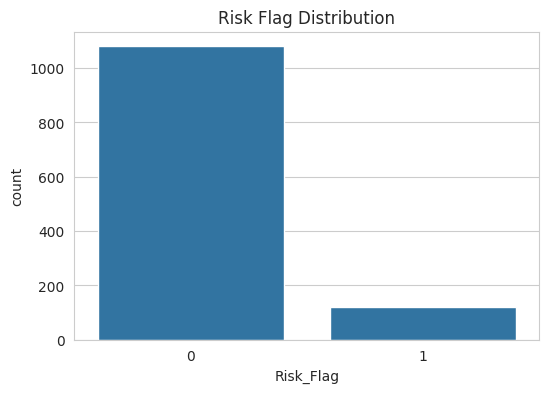

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Risk_Flag",
    data=df
)

plt.title("Risk Flag Distribution")

plt.show()

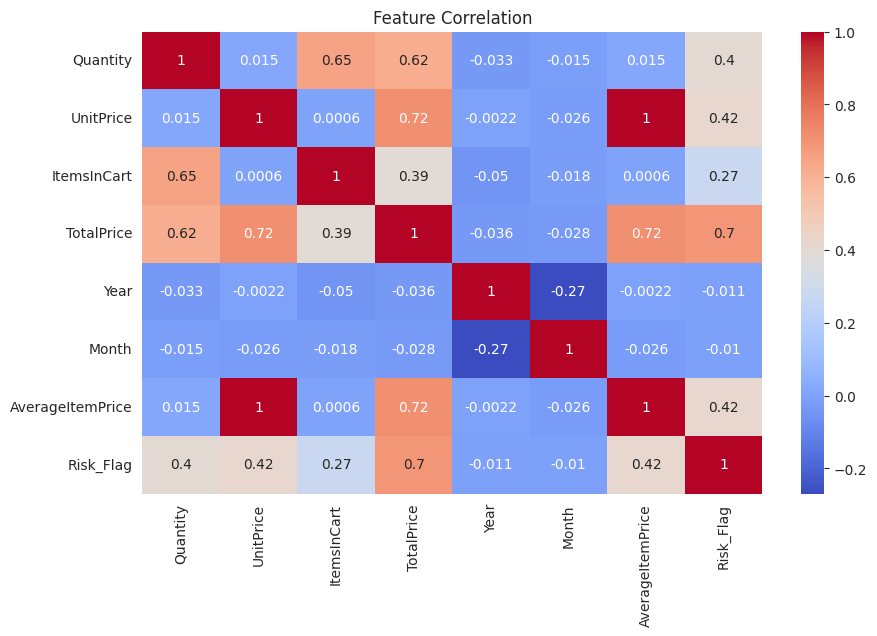

In [29]:
numeric_df = df.select_dtypes(
    include=np.number
)


plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

In [30]:
df.to_csv(
    "processed_fraud_dataset.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully
